# SentinelAI — المرحلة ٣ (جزء ج): شبكة CNN (آخر الخوارزميات السبع)

هذا آخر ملف في مقارنة الخوارزميات السبع. نبني شبكة **1D CNN** (باستخدام
TensorFlow/Keras) تصنّف نوع الهجوم من خصائص التدفّق (Flow Features)، مثل النماذج
الخاضعة للإشراف في `03_supervised.ipynb`، لكن بمعمارية شبكة عصبية بدل خوارزميات
تعلّم آلي كلاسيكية.

نستخدم نفس بيانات `data/processed/` وأوزان الفئات المحفوظة لمعالجة عدم التوازن.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # تقليل رسائل TensorFlow غير المهمة

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style="whitegrid")
tf.random.set_seed(42)

PROCESSED_DIR = os.path.join("..", "data", "processed")
MODELS_DIR = os.path.join("..", "models")
os.makedirs(MODELS_DIR, exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("GPU متاح؟", tf.config.list_physical_devices("GPU") != [])

TensorFlow version: 2.21.0


GPU متاح؟ False


**ماذا فعلنا ولماذا؟**
استوردنا `tensorflow`/`keras` لبناء الشبكة العصبية، بالإضافة لنفس أدوات `scikit-learn`
المستخدمة سابقاً للتقييم. لا يوجد GPU على هذا الجهاز، لذلك سيتم التدريب على المعالج
(CPU) — لهذا اخترنا معمارية بسيطة نسبياً وعدد حقبات (Epochs) صغيراً كما طلبت، حتى يبقى
وقت التدريب معقولاً.

In [2]:
X_train = np.load(os.path.join(PROCESSED_DIR, "X_train.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
y_train = np.load(os.path.join(PROCESSED_DIR, "y_train.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))

with open(os.path.join(PROCESSED_DIR, "label_mapping.json"), encoding="utf-8") as f:
    label_mapping = {int(k): v for k, v in json.load(f).items()}

with open(os.path.join(PROCESSED_DIR, "class_weights.json"), encoding="utf-8") as f:
    class_weights = {int(k): v for k, v in json.load(f).items()}

classes_sorted = sorted(label_mapping.keys())
class_names_sorted = [label_mapping[c] for c in classes_sorted]
n_features = X_train.shape[1]
n_classes = len(classes_sorted)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"عدد الخصائص: {n_features}, عدد الفئات: {n_classes}")

X_train: (908327, 77), X_test: (227082, 77)
عدد الخصائص: 77, عدد الفئات: 11


**ماذا فعلنا ولماذا؟**
حمّلنا نفس بيانات التدريب/الاختبار المُقاسة وأوزان الفئات من المرحلة ٢، تماماً كما في
ملف النماذج الخاضعة للإشراف، حتى تكون المقارنة النهائية بين كل الخوارزميات السبع عادلة.

In [3]:
# مثل XGBoost، طبقة الإخراج في Keras (softmax) تحتاج فئات مرقّمة تسلسلياً من 0،
# بينما فئاتنا الأصلية هي 1..11. نستخدم نفس أسلوب LabelEncoder من ملف Supervised.
label_encoder = LabelEncoder()
label_encoder.fit(y_train)
y_train_encoded = label_encoder.transform(y_train)

# نحوّل قاموس أوزان الفئات (بالفئات الأصلية 1..11) إلى نفس ترقيم 0..10
class_weight_encoded = {
    i: class_weights[original_class]
    for i, original_class in enumerate(label_encoder.classes_)
}
print("أوزان الفئات بعد إعادة الترقيم (0..10):")
print(class_weight_encoded)

أوزان الفئات بعد إعادة الترقيم (0..10):
{0: 0.11728629556249263, 1: 2.938513996590222, 2: 3.0522355961477716, 3: 0.830535703835913, 4: 1.9830259075954424, 5: 13.58591342846032, 6: 50.90948324178904, 7: 342.63560920407394, 8: 1131.1668742216686, 9: 2231.7616707616708, 10: 10321.897727272728}


**ماذا فعلنا ولماذا؟**
حوّلنا فئات `y_train` من 1..11 إلى 0..10 (نفس الحل الذي استخدمناه مع XGBoost)، وأعدنا
بناء قاموس أوزان الفئات بنفس الترقيم الجديد، لأن معامل `class_weight` في Keras يطابق
الفئات بأرقامها المستخدمة فعلياً في التدريب (0..10) وليس الأرقام الأصلية.

In [4]:
X_train_cnn = X_train.reshape(-1, n_features, 1)
X_test_cnn = X_test.reshape(-1, n_features, 1)

print(f"شكل بيانات التدريب بعد إعادة التشكيل: {X_train_cnn.shape}")
print(f"شكل بيانات الاختبار بعد إعادة التشكيل: {X_test_cnn.shape}")

شكل بيانات التدريب بعد إعادة التشكيل: (908327, 77, 1)
شكل بيانات الاختبار بعد إعادة التشكيل: (227082, 77, 1)


**ماذا فعلنا ولماذا؟ (لماذا نعيد تشكيل بيانات جدولية لـ CNN؟)**
طبقة `Conv1D` تتوقّع مدخلاً بشكل `(عدد الصفوف, طول التسلسل, عدد القنوات)`. حوّلنا كل صف
(77 خاصية) إلى "تسلسل" طوله 77 بقناة واحدة: الشكل أصبح `(العدد, 77, 1)` بدل `(العدد, 77)`.

**تنبيه صادق:** خصائص هذا الـ Dataset (مدة التدفّق، عدد الحزم، ...) ليست تسلسلاً زمنياً أو
مكانياً طبيعياً كالصوت أو الصور — ترتيبها في الأعمدة عشوائي نسبياً. لذلك الـ Convolution
هنا لا "يفهم" علاقة فيزيائية حقيقية بين خاصية وجارتها، لكنه عملياً يتصرف كطريقة لتعلّم
توليفات محلية بين أعمدة متجاورة، وهو أسلوب شائع في أبحاث كشف تسلل الشبكات لتطبيق CNN على
بيانات جدولية، رغم أن هذا الافتراض أضعف من استخدام CNN الطبيعي على صور أو صوت.

In [5]:
model = keras.Sequential([
    layers.Input(shape=(n_features, 1)),

    layers.Conv1D(filters=32, kernel_size=3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(filters=64, kernel_size=3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 77, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 77, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 38, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 38, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 38, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        77,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,323 (333.29 KB)

 Trainable params: 85,131 (332.54 KB)

 Non-trainable params: 192 (768.00 B)

**ماذا فعلنا ولماذا؟ (شرح كل طبقة ببساطة)**
- **Conv1D (32 ثم 64 فلتر):** كل فلتر يبحث عن نمط محلي صغير بين 3 خصائص متجاورة.
  استخدمنا طبقتين فقط (بدل شبكة عميقة جداً) لأن بياناتنا جدولية وليست صوراً معقدة.
- **BatchNormalization:** يُثبّت عملية التدريب ويُسرّعها بتوحيد مقياس المخرجات بين الطبقات.
- **MaxPooling1D:** يقلّص حجم البيانات (يأخذ أكبر قيمة من كل زوج) ليقلل التعقيد الحسابي.
- **Flatten + Dense(64):** يحوّل الخرائط الناتجة إلى متجه واحد ثم يتعلّم توليفة نهائية منها.
- **Dropout(0.3):** يُطفئ 30% من الخلايا عشوائياً أثناء التدريب فقط، لتقليل الحفظ الزائد
  (Overfitting).
- **Dense(11, softmax):** طبقة الإخراج — تعطي احتمال كل فئة من الفئات الـ11، ومجموعها 1.

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

**ماذا فعلنا ولماذا؟**
استخدمنا `sparse_categorical_crossentropy` (مناسبة عندما تكون الفئات أرقاماً صحيحة مثل
0..10، بدل One-Hot Encoding الذي يحتاج ذاكرة أكبر). المُحسِّن `adam` هو خيار قياسي وموثوق
يعمل جيداً في أغلب الحالات دون ضبط يدوي كثير.

In [7]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True,
)

start = time.time()
history = model.fit(
    X_train_cnn, y_train_encoded,
    validation_split=0.1,
    epochs=10,
    batch_size=2048,
    class_weight=class_weight_encoded,
    callbacks=[early_stop],
    verbose=2,
)
cnn_train_time = time.time() - start
print(f"\nوقت تدريب CNN: {cnn_train_time:.1f} ثانية ({cnn_train_time/60:.1f} دقيقة)")

Epoch 1/10


400/400 - 42s - 106ms/step - accuracy: 0.6517 - loss: 1.6548 - val_accuracy: 0.8195 - val_loss: 0.5896


Epoch 2/10


400/400 - 43s - 108ms/step - accuracy: 0.7819 - loss: 0.9010 - val_accuracy: 0.8689 - val_loss: 0.3934


Epoch 3/10


...

Epoch 9/10


400/400 - 46s - 115ms/step - accuracy: 0.9026 - loss: 0.3990 - val_accuracy: 0.9361 - val_loss: 0.2558


Epoch 10/10


400/400 - 46s - 114ms/step - accuracy: 0.8965 - loss: 0.3495 - val_accuracy: 0.9048 - val_loss: 0.2905



وقت تدريب CNN: 451.1 ثانية (7.5 دقيقة)


**ماذا فعلنا ولماذا؟**
دربنا الشبكة لعدد صغير من الحقبات (`epochs=10`) كما طلبت، مع تخصيص 10% من بيانات
التدريب للتحقق (`validation_split=0.1`) لمراقبة الأداء على بيانات لم تُستخدم في التدريب
المباشر. استخدمنا `class_weight` (نفس أوزان الفئات) لإعطاء الفئات النادرة اهتماماً أكبر
في دالة الخسارة. أضفنا `EarlyStopping`: لو توقّف تحسّن الأداء على بيانات التحقق لـ 3
حقبات متتالية، يتوقف التدريب تلقائياً ويستعيد أفضل أوزان — هذا يمنع إضاعة وقت إضافي أو
الحفظ الزائد (Overfitting) دون أن نضطر لتخمين العدد الأمثل للحقبات يدوياً.

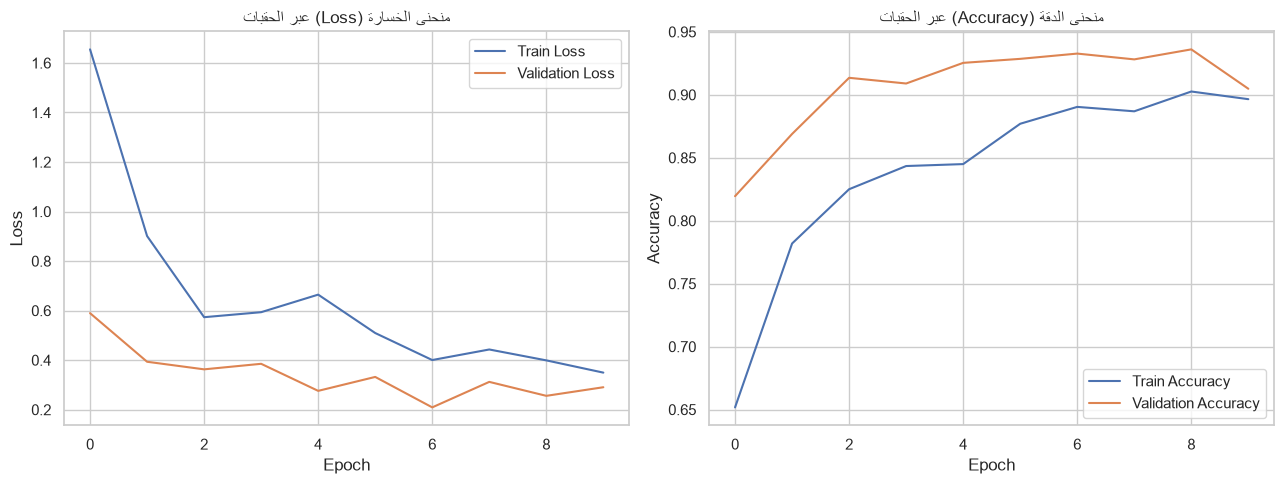

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("منحنى الخسارة (Loss) عبر الحقبات")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("منحنى الدقة (Accuracy) عبر الحقبات")
axes[1].legend()

plt.tight_layout()
plt.show()

**ماذا فعلنا ولماذا؟**
رسمنا منحنى الخسارة والدقة لكل من بيانات التدريب والتحقق معاً. هذا يساعدنا نكتشف بصرياً:
لو ابتعد منحنى التدريب عن منحنى التحقق (تدريب يتحسّن باستمرار بينما التحقق يسوء أو يثبت)،
فهذا دليل Overfitting. لو تحسّن الاثنان معاً وتقاربا، فالنموذج يتعلّم بشكل صحي.

===== CNN (1D Convolutional Neural Network) =====
Accuracy:          0.9330
Precision (macro): 0.6204
Recall (macro):    0.9565
F1-score (macro):  0.6474

              precision    recall  f1-score   support

      Benign       1.00      0.91      0.95    176012
    Attack_2       1.00      1.00      1.00      7026
    Attack_3       1.00      1.00      1.00      6763
    Attack_4       0.97      1.00      0.98     24856
    Attack_5       0.95      1.00      0.98     10410
    Attack_6       0.90      1.00      0.95      1520
    Attack_7       0.21      1.00      0.35       406
    Attack_8       0.77      1.00      0.87        60
    Attack_9       0.01      0.61      0.03        18
   Attack_10       0.00      1.00      0.00         9
   Attack_11       0.01      1.00      0.01         2

    accuracy                           0.93    227082
   macro avg       0.62      0.96      0.65    227082
weighted avg       0.99      0.93      0.96    227082



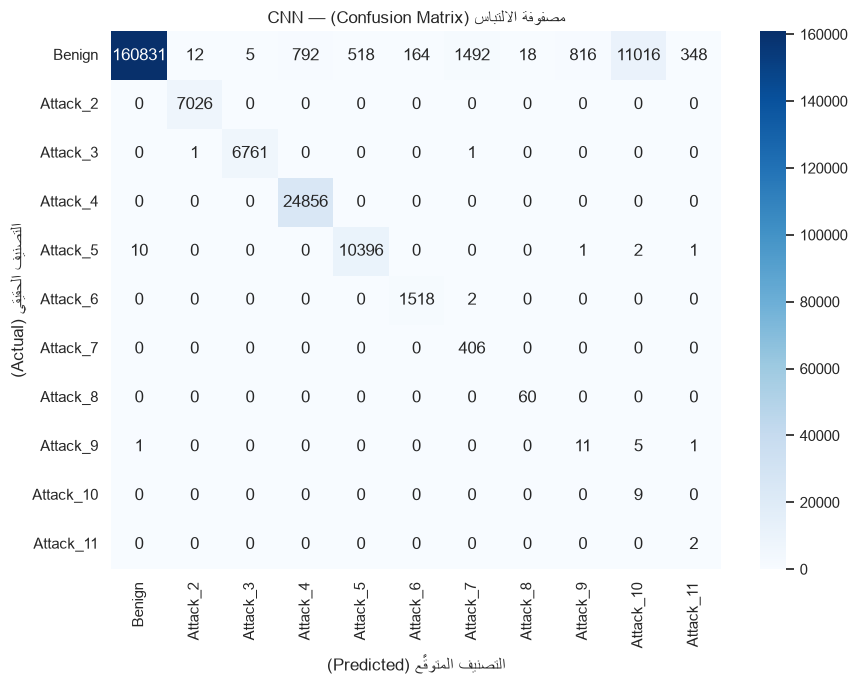

In [9]:
y_pred_proba = model.predict(X_test_cnn, verbose=0)
y_pred_encoded = np.argmax(y_pred_proba, axis=1)
y_pred = label_encoder.inverse_transform(y_pred_encoded)

acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="macro", zero_division=0
)

print("===== CNN (1D Convolutional Neural Network) =====")
print(f"Accuracy:          {acc:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"F1-score (macro):  {f1:.4f}\n")
print(classification_report(
    y_test, y_pred, labels=classes_sorted, target_names=class_names_sorted, zero_division=0,
))

cm = confusion_matrix(y_test, y_pred, labels=classes_sorted)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names_sorted, yticklabels=class_names_sorted)
plt.xlabel("التصنيف المتوقَّع (Predicted)")
plt.ylabel("التصنيف الحقيقي (Actual)")
plt.title("مصفوفة الالتباس (Confusion Matrix) — CNN")
plt.tight_layout()
plt.show()

cnn_metrics = {
    "Accuracy": acc, "Precision (macro)": precision,
    "Recall (macro)": recall, "F1-score (macro)": f1,
    "Training Time (s)": cnn_train_time,
}

**ماذا فعلنا ولماذا؟**
قيّمنا الشبكة على بيانات الاختبار (نفس 227,082 صف المستخدمة مع النماذج الخاضعة للإشراف)
بنفس المقاييس بالضبط (Accuracy، Precision/Recall/F1 بطريقة Macro، ومصفوفة التباس)، حتى
تكون المقارنة النهائية بين الخوارزميات السبع عادلة تماماً. حوّلنا توقعات الشبكة
(احتمالات لكل فئة عبر `softmax`) إلى فئة واحدة بأخذ الفئة صاحبة أعلى احتمال (`argmax`)،
ثم أعدناها للترقيم الأصلي (1..11) عبر `label_encoder.inverse_transform`.

In [10]:
model_path = os.path.join(MODELS_DIR, "cnn_model.keras")
model.save(model_path)

encoder_path = os.path.join(MODELS_DIR, "cnn_label_encoder.joblib")
joblib.dump(label_encoder, encoder_path)

with open(os.path.join(MODELS_DIR, "cnn_history.json"), "w", encoding="utf-8") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history.history.items()}, f, indent=2)

pd.DataFrame([cnn_metrics], index=["CNN (1D Conv)"]).round(4).to_csv(
    os.path.join(MODELS_DIR, "cnn_comparison.csv")
)

print(f"تم حفظ نموذج CNN -> {model_path} ({os.path.getsize(model_path) / (1024*1024):.2f} MB)")
print(f"تم حفظ LabelEncoder -> {encoder_path}")
print("تم حفظ سجل التدريب (cnn_history.json) ونتائج المقارنة (cnn_comparison.csv)")

تم حفظ نموذج CNN -> ..\models\cnn_model.keras (1.02 MB)
تم حفظ LabelEncoder -> ..\models\cnn_label_encoder.joblib
تم حفظ سجل التدريب (cnn_history.json) ونتائج المقارنة (cnn_comparison.csv)


**ماذا فعلنا ولماذا؟**
حفظنا نموذج CNN بصيغة `.keras` (الصيغة الحديثة الموصى بها في TensorFlow) في `models/`،
بالإضافة إلى `LabelEncoder` الخاص به (ضروري لأي استخدام مستقبلي، تماماً كحالة XGBoost)،
وسجل التدريب (لإعادة رسم المنحنيات لاحقاً دون إعادة التدريب)، وجدول نتائج مختصر
(`cnn_comparison.csv`) لدمجه مع جداول المرحلة السابقة عند اختيار أفضل نموذج.

## الخلاصة

بنينا ودربنا شبكة **1D CNN** — آخر الخوارزميات السبع المطلوبة من الدكتور — وقيّمناها
بنفس مقاييس النماذج الخاضعة للإشراف، وحفظنا النموذج المدرَّب وكل ما يلزم لإعادة استخدامه
في `models/`.

**الآن اكتملت الخوارزميات السبع:**
- Supervised: Random Forest، Logistic Regression، Gradient Boosting (XGBoost)
- Unsupervised: K-Means، DBSCAN، Isolation Forest
- Deep Learning: 1D CNN

**الخطوة القادمة (كما اتفقنا):** مقارنة كل النتائج معاً، اختيار أفضل نموذج عموماً، ثم
تحسين إعداداته (Hyperparameter Tuning) — لم نبدأ هذه الخطوة بعد.